In [1]:
import numpy as np
import gym
import random
from IPython.display import clear_output
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
# Create FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="ansi")

# Environment details
print("Action Space:", env.action_space)
print("Observation Space:", env.observation_space)

Action Space: Discrete(4)
Observation Space: Discrete(16)


In [3]:
# Create Q-table (16 states x 4 actions)
state_size = env.observation_space.n
action_size = env.action_space.n
qtable = np.zeros((state_size, action_size))

print("Q-table shape:", qtable.shape)
print("Initial Q-table:")
print(qtable)

Q-table shape: (16, 4)
Initial Q-table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [4]:
# Learning parameters
total_episodes = 10000        # Total training episodes
learning_rate = 0.8           # Learning rate
max_steps = 99                # Max steps per episode
gamma = 0.95                  # Discounting rate

# Exploration parameters
epsilon = 1.0                 # Exploration rate
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.01            # Minimum exploration probability 
decay_rate = 0.005            # Exponential decay rate for exploration

In [ ]:
# List to store rewards
rewards = []

# Training loop (FIXED VERSION)
for episode in range(total_episodes):
    # Reset the environment - handle different gym versions
    result = env.reset()
    if isinstance(result, tuple):
        state = result[0]  # Newer gym versions return (state, info)
    else:
        state = result     # Older gym versions return just state
    
    step = 0
    done = False
    total_rewards = 0
    
    for step in range(max_steps):
        # Exploration-exploitation tradeoff
        if random.uniform(0, 1) > epsilon:
            action = np.argmax(qtable[state, :])  # Exploitation
        else:
            action = env.action_space.sample()    # Exploration
        
        # Take the action - handle different gym versions
        step_result = env.step(action)
        if len(step_result) == 4:
            # Older gym version: (state, reward, done, info)
            new_state, reward, done, info = step_result
            truncated = False
        else:
            # Newer gym version: (state, reward, done, truncated, info)
            new_state, reward, done, truncated, info = step_result
        
        # Update Q-table using Bellman equation
        qtable[state, action] = qtable[state, action] + learning_rate * (
            reward + gamma * np.max(qtable[new_state, :]) - qtable[state, action]
        )
        
        total_rewards += reward
        state = new_state
        
        if done or truncated:
            break
    
    # Reduce epsilon (less exploration over time)
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards.append(total_rewards)
    # Print progress
    if (episode + 1) % 1000 == 0:
        clear_output(wait=True)
        print(f"Episode {episode + 1}/{total_episodes}")
        success_rate = np.mean(rewards[-100:]) * 100
        print(f"Last 100 episodes success rate: {success_rate:.1f}%")

print("Training finished!")

In [12]:
import gymnasium as gym  # Use gymnasium instead of gym

def evaluate_agent(episodes=100):
    env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="ansi")
    wins = 0
    
    for episode in range(episodes):
        state, info = env.reset()  # gymnasium always returns (state, info)
        done = False
        
        print(f"Episode {episode + 1}")
        
        while not done:
            action = np.argmax(qtable[state, :])
            state, reward, done, truncated, info = env.step(action)
            
            if done or truncated:
                if reward == 1:
                    wins += 1
                    print("🏆 Success! Reached the goal!")
                else:
                    print("💥 Fell into a hole!")
                break
    
    env.close()
    print(f"Success rate: {wins/episodes * 100:.1f}%")
    return wins/episodes

# Evaluate the trained agent
success_rate = evaluate_agent(10)

Episode 1
🏆 Success! Reached the goal!
Episode 2
🏆 Success! Reached the goal!
Episode 3
🏆 Success! Reached the goal!
Episode 4
🏆 Success! Reached the goal!
Episode 5
🏆 Success! Reached the goal!
Episode 6
🏆 Success! Reached the goal!
Episode 7
🏆 Success! Reached the goal!
Episode 8
💥 Fell into a hole!
Episode 9
🏆 Success! Reached the goal!
Episode 10
🏆 Success! Reached the goal!
Success rate: 90.0%


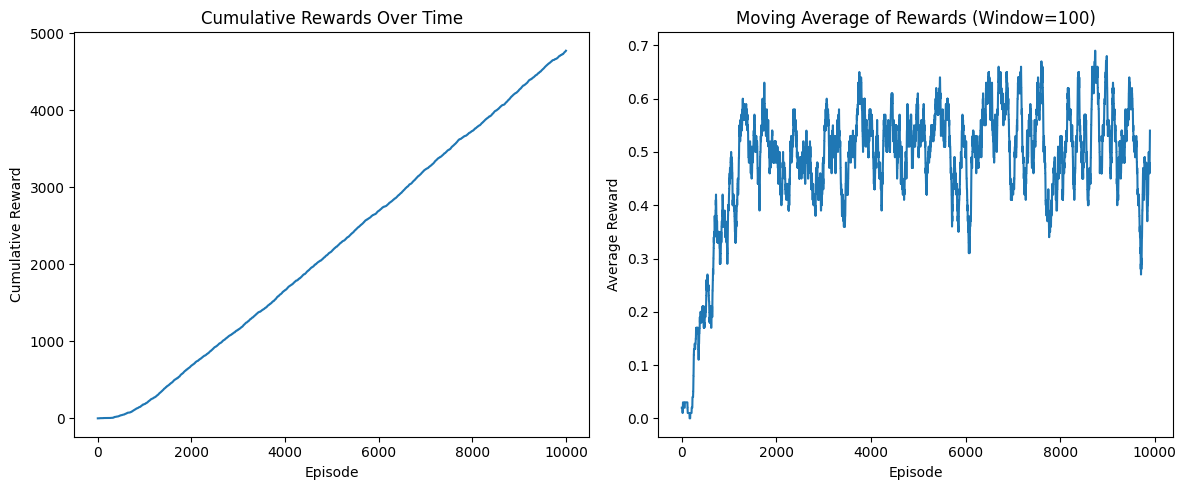

Final Q-table:
[[4.02562847e-01 4.76956453e-02 5.44672036e-02 5.25615084e-02]
 [5.49911621e-04 6.27180828e-03 4.68549996e-03 2.94810826e-01]
 [4.44038132e-03 1.30985617e-03 8.68513234e-03 4.54898491e-02]
 [8.33060313e-03 4.46118239e-04 3.02837918e-03 1.32423693e-02]
 [5.06112451e-01 1.42638804e-03 9.23803290e-03 7.77586478e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.48190534e-02 4.77808090e-06 9.85107349e-06 6.02966227e-10]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.09267076e-01 5.01087344e-03 4.12903893e-02 3.12487343e-01]
 [3.36046662e-04 7.69718916e-01 1.32809808e-03 1.09979989e-02]
 [7.05464034e-01 7.54958890e-04 2.98916539e-04 7.96789330e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [3.98277726e-02 1.39146788e-03 9.19799053e-01 1.58256290e-01]
 [1.73321029e-01 9.84971225e-01 7.92882513e-01 1.66764850e-01]
 [0.00000000e+00 0.00000000e+00 0.000000

In [13]:
# Plot rewards over time
plt.figure(figsize=(12, 5))

# Plot 1: Cumulative rewards
plt.subplot(1, 2, 1)
plt.plot(np.cumsum(rewards))
plt.title('Cumulative Rewards Over Time')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')

# Plot 2: Moving average of rewards
plt.subplot(1, 2, 2)
window = 100
moving_avg = [np.mean(rewards[i-window:i]) for i in range(window, len(rewards))]
plt.plot(moving_avg)
plt.title('Moving Average of Rewards (Window=100)')
plt.xlabel('Episode')
plt.ylabel('Average Reward')

plt.tight_layout()
plt.show()

print("Final Q-table:")
print(qtable)